<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Practica_5_CNN_Reconocimiento_Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [19]:
#El conjunto de datos CIFAR-10 contiene imágenes a color de 32 x 32 píxeles distribuidas
#en 10 clases. Estas imágenes se dividen en datos de entrenamiento y datos de prueba.
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [20]:
#Cada imagen pertenece a una de las diez clases disponibles en CIFAR-10.
clases = [
    "Avión",
    "Automóvil",
    "Ave",
    "Gato",
    "Venado",
    "Perro",
    "Rana",
    "Caballo",
    "Barco",
    "Camión"
]

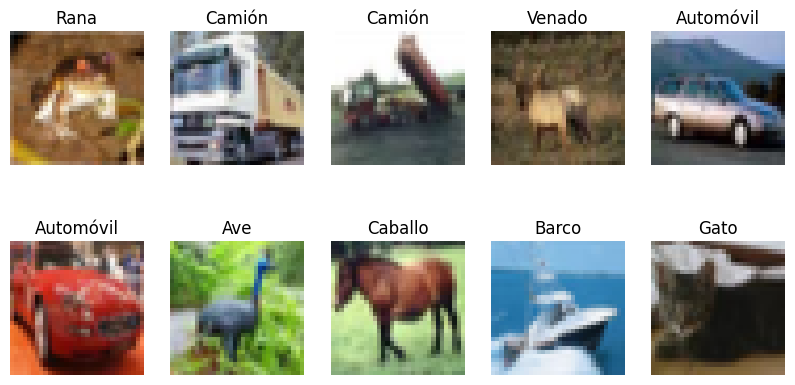

In [21]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(clases[y_train[i][0]])
    plt.axis("off")

plt.show()

In [22]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

#La salida mostrará la cantidad de imágenes, el tamaño de cada imagen y el número de
#canales de color. Cada imagen tiene dimensiones de 32 x 32 píxeles con 3 canales de
#color: rojo, verde y azul.

Forma de X_train: (50000, 32, 32, 3)
Forma de y_train: (50000, 1)
Forma de X_test: (10000, 32, 32, 3)
Forma de y_test: (10000, 1)


In [23]:
#Los valores de los píxeles van de 0 a 255. Para facilitar el entrenamiento de la red
#neuronal, se normalizan dividiendo entre 255.
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
#Como CIFAR-10 tiene 10 clases, las etiquetas deben convertirse a formato categórico.
#Este proceso transforma cada etiqueta en un vector de 10 posiciones, donde la posición
#correspondiente a la clase correcta toma el valor de 1.
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

###Una red neuronal convolucional se compone principalmente de las siguientes capas:

• Capa convolucional: extrae características visuales de la imagen.
• Capa de agrupamiento o pooling: reduce el tamaño de la información conservando ca
racterísticas importantes.
• Capa Flatten: convierte los mapas de características en un vector.
• Capa densa: realiza la clasificación final.
• Capa de salida: genera la probabilidad de pertenencia a cada clase.
La estructura general será:

Imagen → Convolución → Pooling → Convolución → Pooling → Flatten → Dense → Cla
sificación

In [24]:
modelo = Sequential()
modelo.add(Conv2D(
filters=32,
kernel_size=(3, 3),
activation="relu",
input_shape=(32, 32, 3)
))
modelo.add(MaxPooling2D(pool_size=(2, 2)))
modelo.add(Conv2D(
filters=64,
kernel_size=(3, 3),
activation="relu"
))
modelo.add(MaxPooling2D(pool_size=(2, 2)))
modelo.add(Flatten())
modelo.add(Dense(128, activation="relu"))
modelo.add(Dropout(0.5))
modelo.add(Dense(10, activation="softmax"))

###En esta arquitectura:

• Conv2D aplica filtros sobre la imagen para detectar características.
• MaxPooling2D reduce el tamaño de los mapas de características.
• Flatten convierte la información en un vector.
• Dense conecta las neuronas para realizar la clasificación.
• Dropout ayuda a reducir el sobreajuste.
• softmax permite obtener probabilidades para las 10 clases.

In [25]:
modelo.summary()
#El resumen permite observar la cantidad de capas, la forma de salida de cada capa y el
#número de parámetros entrenables.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
modelo.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)

In [27]:
historial = modelo.fit(
X_train,
y_train_cat,
epochs=10, #son los ciclos completos en el que todo el conjunto de datos de
#entrenamiento pasa una vez hacia adelante y una vez hacia atras a traves de la red
batch_size=64,
validation_split=0.2
)

#Durante el entrenamiento, observa los valores de pérdida y exactitud tanto en
#entrenamiento como en validación.

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - accuracy: 0.3825 - loss: 1.6839 - val_accuracy: 0.5186 - val_loss: 1.3706
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.4984 - loss: 1.3930 - val_accuracy: 0.5646 - val_loss: 1.2232
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.5505 - loss: 1.2640 - val_accuracy: 0.5968 - val_loss: 1.1478
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.5784 - loss: 1.1906 - val_accuracy: 0.6361 - val_loss: 1.0468
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.6023 - loss: 1.1208 - val_accuracy: 0.6419 - val_loss: 1.0170
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.6243 - loss: 1.0690 - val_accuracy: 0.6536 - val_loss: 0.9974
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.6409 - loss: 1.0206 - val_accuracy: 0.6739 - val_loss: 0.9419
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6572 - loss: 0.9785 - 

In [33]:
perdida, exactitud = modelo.evaluate(X_test, y_test_cat)
print("Pérdida en prueba:", perdida)
print("Exactitud en prueba:", exactitud)

#La pérdida indica qué tanto se equivoca el modelo. La exactitud indica el porcentaje de
#imágenes clasificadas correctamente.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6844 - loss: 0.9089
Pérdida en prueba: 0.9089301824569702
Exactitud en prueba: 0.6844000220298767


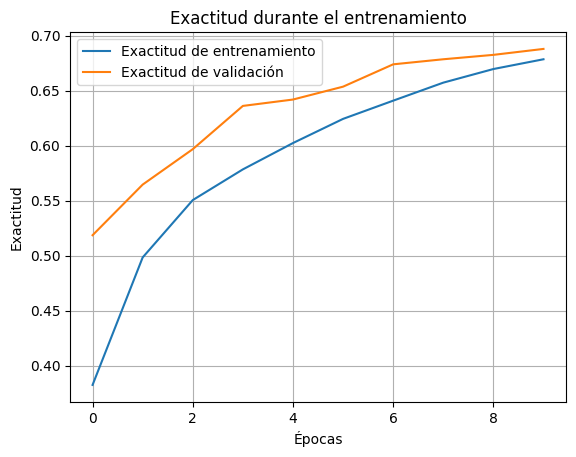

In [34]:
plt.plot(historial.history["accuracy"], label="Exactitud de entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Exactitud de validación")
plt.title("Exactitud durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.legend()
plt.grid(True)
plt.show()

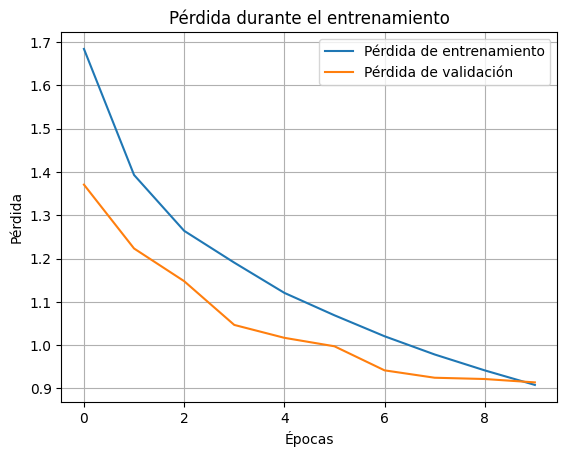

In [35]:
plt.plot(historial.history["loss"], label="Pérdida de entrenamiento")
plt.plot(historial.history["val_loss"], label="Pérdida de validación")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


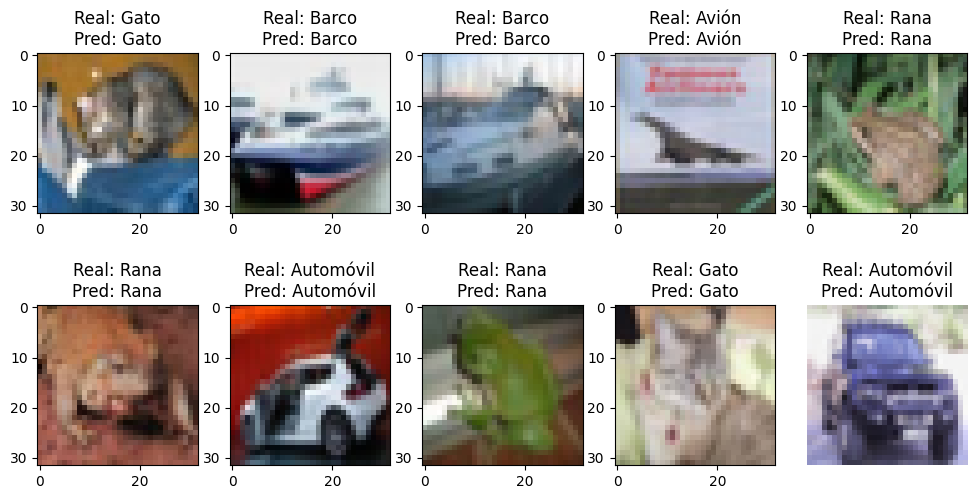

In [36]:
predicciones = modelo.predict(X_test)

plt.figure(figsize=(12, 6))

for i in range(10):
  clase_real = y_test[i][0]
  clase_predicha = np.argmax(predicciones[i])
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[i])
  plt.title(
  "Real: " + clases[clase_real] + "\nPred: " + clases[clase_predicha]
)
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


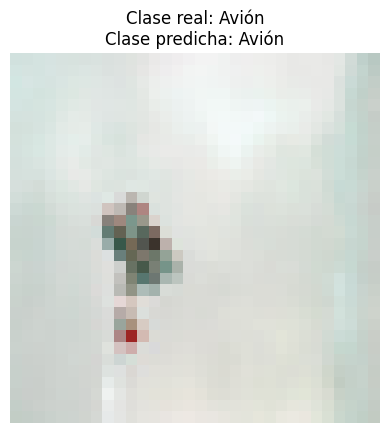

Probabilidades por clase:
Avión : 0.42575684
Automóvil : 0.0029961078
Ave : 0.15762806
Gato : 0.19116645
Venado : 0.07356865
Perro : 0.05675919
Rana : 0.055889197
Caballo : 0.008824175
Barco : 0.024794998
Camión : 0.0026163012


In [38]:
indice = 313 #imagen a seleccionar de las 313 del conjunto de prueba (prediccion
#generada por el modelo)
imagen = X_test[indice]
imagen_expandida = np.expand_dims(imagen, axis=0)
prediccion = modelo.predict(imagen_expandida)
clase_predicha = np.argmax(prediccion)
clase_real = y_test[indice][0]
plt.imshow(imagen)
plt.title(
  "Clase real: " + clases[clase_real] +
  "\nClase predicha: " + clases[clase_predicha]
)
plt.axis("off")
plt.show()

print("Probabilidades por clase:")
for i in range(10):
  print(clases[i], ":", prediccion[0][i])

## Actividad de integración


1. ¿Qué es Deep Learning?
Es una rama del aprendizaje automático que utiliza redes neuronales con múltiples capas para analizar datos complejos y aprender características y patrones, para el reconocimiento y clasificación de imágenes.

2. ¿Qué es TensorFlow?
Biblioteca de código abierto utilizada para construir, entrenar y evaluar modelos de aprendizaje automático y aprendizaje profundo, permite trabajar con operaciones matemáticas, redes neuronales y grandes cantidades de datos.

3. ¿Qué es Keras?
Interfaz de alto nivel integrada en TensorFlow que facilita la creación de redes neuronales mediante diferentes capas, como convolución, agrupamiento, aplanamiento y capas densas.

4. ¿Qué es CIFAR-10?
Son datos utilizados para tareas de reconocimiento y clasificación de imágenes y contiene imágenes a color de 32 × 32 píxeles.

5. ¿Qué es una red neuronal convolucional?
Red neuronal diseñada para trabajar principalmente con imágenes. Utiliza filtros o kernels para extraer características visuales como bordes, texturas, curvas, formas y patrones, que posteriormente utiliza para clasificar las imágenes.

6. ¿Cuál es la diferencia entre una red neuronal tradicional y una CNN?
Red neuronal tradicional suele procesar los datos como una lista de valores
Una CNN conserva la estructura espacial de la imagen y considera la relación entre los píxeles cercanos.

7. ¿Qué tipo de datos se utilizaron en esta práctica?
Se utilizaron imágenes a color del conjunto de datos CIFAR-10, con dimensiones de 32 × 32 píxeles y tres canales de color: rojo, verde y azul (RGB).

8. ¿Para qué sirve una capa convolucional?
Para extraer características visuales de las imágenes mediante filtros que detectan elementos como bordes, texturas, formas y patrones.

9. ¿Qué función cumple la capa MaxPooling2D?
Reduce el tamaño de los mapas de características, conservando la información más importante. Esto ayuda a disminuir la cantidad de información que debe procesar la red.

10. ¿Para qué se utiliza la capa Flatten?
Convierte mapas de características obtenidos por las capas anteriores en un vector, para que puedan ser procesados por las capas densas.

11. ¿Qué función cumple la capa Dense?
Conecta neuronas para realizar la clasificación. En el modelo de la práctica se utiliza una capa Dense de 128 neuronas y otra de 10 neuronas para las clases de CIFAR-10.

12. ¿Por qué se utiliza softmax en la capa de salida?
Para obtener las probabilidades de pertenencia de una imagen a cada una de las 10 clases. La clase con el valor de probabilidad más alto representa la predicción del modelo.

13. ¿Qué representa la exactitud del modelo?
Porcentaje de imágenes que el modelo clasifica correctamente. Una mayor exactitud indica que el modelo está realizando correctamente un mayor número de clasificaciones.

14. ¿Qué representa la pérdida del modelo?
Que tanto se equivoca el modelo durante la clasificación. Cuando la pérdida disminuye, significa que el error del modelo se está reduciendo.

15. ¿El modelo logró clasificar correctamente las imágenes?
Si, puede clasificar correctamente algunas de las imágenes, siempre que las predicciones coincidan con las clases reales